
# Exercise 2

Let
$$
X \sim \mathrm{Exp}(1), \qquad h(x,u)=(x-u)^2, \qquad f(u)=\mathbb{E}[h(X,u)], \qquad u\in[0,2].
$$

We train a neural network $g_\theta$ such that

- $g_\theta(u)\approx f(u)$,
- $(g_\theta)'(u)\approx f'(u)$.




## Analytical derivation

Since
$$
f(u)=\mathbb{E}\big[(X-u)^2\big]
=\mathbb{E}[X^2]-2u\,\mathbb{E}[X]+u^2,
$$
and for $X\sim \mathrm{Exp}(1)$ we have
$$
\mathbb{E}[X]=1, \qquad \mathrm{Var}(X)=1, \qquad \mathbb{E}[X^2]=2,
$$
it follows that
$$
f(u)=u^2-2u+2,
\qquad
f'(u)=2u-2.
$$

Also,
$$
\partial_u h(x,u)=2(u-x),
$$
so
$$
f'(u)=\mathbb{E}[\partial_u h(X,u)].
$$

For each training input $u_i$, we simulate several samples $X_{ij}\sim\mathrm{Exp}(1)$ and define
$$
y_i=\frac1M\sum_{j=1}^M (X_{ij}-u_i)^2,
\qquad
z_i=\frac1M\sum_{j=1}^M 2(u_i-X_{ij}).
$$

We then minimize
$$
\mathcal{L}(\theta)
=
\frac1N\sum_{i=1}^N\big(g_\theta(u_i)-y_i\big)^2
+
\lambda \frac1N\sum_{i=1}^N\big((g_\theta)'(u_i)-z_i\big)^2.
$$

Thus the network is trained to match both function values and derivatives.


In [1]:

# Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam


In [2]:

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [3]:

# Exact formulas for checking
def f_true(u):
    return u**2 - 2*u + 2

def df_true(u):
    return 2*u - 2


In [4]:

# Monte Carlo data generation
def generate_data(N=400, M=50):
    # Sample inputs uniformly from [0, 2]
    u = np.random.uniform(0.0, 2.0, size=(N, 1)).astype("float32")

    # Simulate X ~ Exp(1), shape = (N, M)
    X = np.random.exponential(scale=1.0, size=(N, M)).astype("float32")

    # Monte Carlo approximation of f(u) = E[(X-u)^2]
    y = np.mean((X - u)**2, axis=1, keepdims=True).astype("float32")

    # Monte Carlo approximation of f'(u) = E[2(u-X)]
    z = np.mean(2.0 * (u - X), axis=1, keepdims=True).astype("float32")

    return u, y, z


In [5]:

# Create training and test data
# We use more samples per u for the test set to obtain a cleaner benchmark.
u_train, y_train, z_train = generate_data(N=400, M=50)
u_test,  y_test,  z_test  = generate_data(N=200, M=200)

print("Training set shapes:")
print("u_train:", u_train.shape)
print("y_train:", y_train.shape)
print("z_train:", z_train.shape)


Training set shapes:
u_train: (400, 1)
y_train: (400, 1)
z_train: (400, 1)


In [6]:

# Build the neural network
def build_model(hidden_layers=(64, 64, 32)):
    inp = Input(shape=(1,))
    x = inp
    for units in hidden_layers:
        x = Dense(units, activation="tanh")(x)
    out = Dense(1, activation="linear")(x)  # linear readout for regression
    return Model(inputs=inp, outputs=out)

model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)


## Why use a custom training loop?

A standard `model.fit(...)` is not enough here because the loss depends on both

- the network output $g_\theta(u)$,
- the network derivative $(g_\theta)'(u)$.

So we use `tf.GradientTape()` to compute the derivative with respect to the input and then optimize the combined loss with Adam.


In [13]:
# Training function
def train_model(model, u_train, y_train, z_train,
                epochs=1500, lr=1e-3, lambda_deriv=1.0):

    optimizer = Adam(learning_rate=lr)

    u_train = tf.convert_to_tensor(u_train)
    y_train = tf.convert_to_tensor(y_train)
    z_train = tf.convert_to_tensor(z_train)

    value_losses = []
    deriv_losses = []
    total_losses = []

    for epoch in range(epochs):
        with tf.GradientTape() as tape_theta:
            with tf.GradientTape() as tape_u:
                tape_u.watch(u_train)
                g_pred = model(u_train, training=True)

            dg_pred = tape_u.gradient(g_pred, u_train)

            value_loss = tf.reduce_mean((g_pred - y_train)**2)
            deriv_loss = tf.reduce_mean((dg_pred - z_train)**2)
            total_loss = value_loss + lambda_deriv * deriv_loss

        grads = tape_theta.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        value_losses.append(value_loss.numpy())
        deriv_losses.append(deriv_loss.numpy())
        total_losses.append(total_loss.numpy())

        if epoch % 300 == 0:
            print(f"Epoch {epoch:4d} | total loss = {total_loss.numpy():.6f}")

    return value_losses, deriv_losses, total_losses


In [14]:

# Train the model
value_losses, deriv_losses, total_losses = train_model(
    model, u_train, y_train, z_train,
    epochs=1500, lr=1e-3, lambda_deriv=1.0
)


Epoch    0 | total loss = 0.230668
Epoch  300 | total loss = 0.230468
Epoch  600 | total loss = 0.230250
Epoch  900 | total loss = 0.230068
Epoch 1200 | total loss = 0.229960


In [15]:

# Evaluate on a dense grid
u_grid = np.linspace(0.0, 2.0, 400).reshape(-1, 1).astype("float32")
u_grid_tf = tf.convert_to_tensor(u_grid)

with tf.GradientTape() as tape:
    tape.watch(u_grid_tf)
    g_grid = model(u_grid_tf, training=False)
dg_grid = tape.gradient(g_grid, u_grid_tf)

g_grid = g_grid.numpy().flatten()
dg_grid = dg_grid.numpy().flatten()

f_grid = f_true(u_grid.flatten())
df_grid = df_true(u_grid.flatten())


In [16]:

# Numerical comparison
value_mse_exact = np.mean((g_grid - f_grid)**2)
deriv_mse_exact = np.mean((dg_grid - df_grid)**2)

print("Grid MSE against exact f(u):     ", value_mse_exact)
print("Grid MSE against exact f'(u):    ", deriv_mse_exact)


Grid MSE against exact f(u):      0.00017992695
Grid MSE against exact f'(u):     0.00022290266


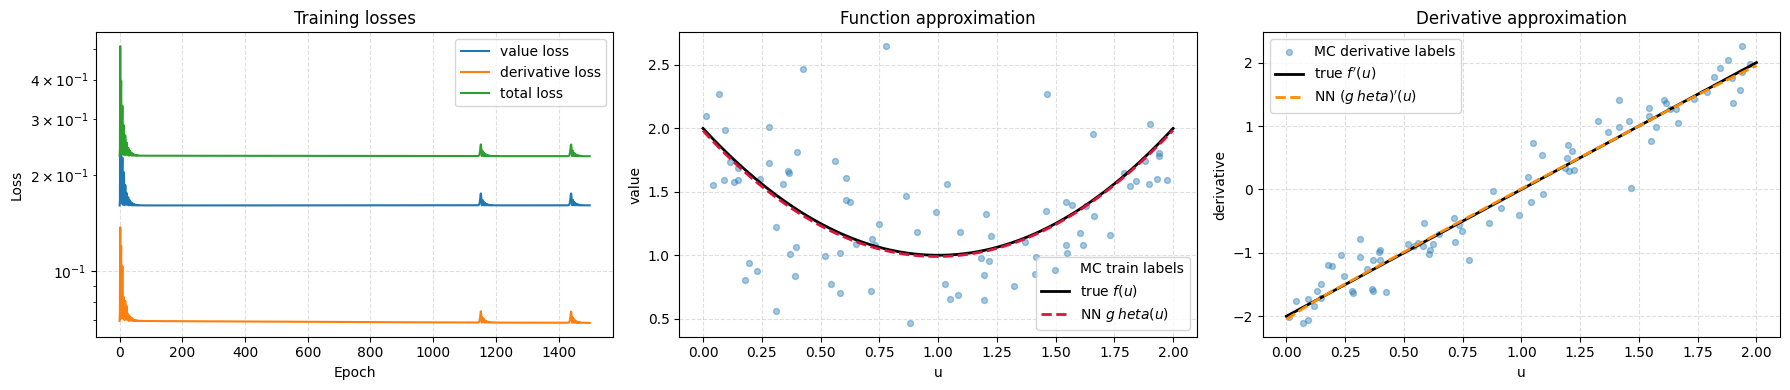

In [17]:

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss curves
axes[0].semilogy(value_losses, label="value loss")
axes[0].semilogy(deriv_losses, label="derivative loss")
axes[0].semilogy(total_losses, label="total loss")
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].legend()

# Function approximation
axes[1].scatter(u_train[:80], y_train[:80], s=18, alpha=0.4, label="MC train labels")
axes[1].plot(u_grid, f_grid, color="black", lw=2, label="true $f(u)$")
axes[1].plot(u_grid, g_grid, "--", color="crimson", lw=2, label="NN $g_\theta(u)$")
axes[1].set_title("Function approximation")
axes[1].set_xlabel("u")
axes[1].set_ylabel("value")
axes[1].grid(True, ls="--", alpha=0.4)
axes[1].legend()

# Derivative approximation
axes[2].scatter(u_train[:80], z_train[:80], s=18, alpha=0.4, label="MC derivative labels")
axes[2].plot(u_grid, df_grid, color="black", lw=2, label="true $f'(u)$")
axes[2].plot(u_grid, dg_grid, "--", color="darkorange", lw=2, label="NN $(g_\theta)'(u)$")
axes[2].set_title("Derivative approximation")
axes[2].set_xlabel("u")
axes[2].set_ylabel("derivative")
axes[2].grid(True, ls="--", alpha=0.4)
axes[2].legend()

plt.tight_layout()
plt.show()



## Final written answer

### How should the derivative approximation be included?

It should be included through an additional loss term.  
For each input $u_i$, we compute a Monte Carlo label for the function value and a Monte Carlo label for the derivative, and then minimize

$$
\mathcal{L}(\theta)
=
\frac1N\sum_{i=1}^N \big(g_\theta(u_i)-y_i\big)^2
+
\lambda \frac1N\sum_{i=1}^N \big((g_\theta)'(u_i)-z_i\big)^2.
$$

### Comment on the strategy

The method is intentionally simple:

1. use a small dense feed-forward network,
2. keep the regression setup with MSE-type losses,
3. add a derivative loss term,
4. use several samples per input to reduce Monte Carlo noise,
5. use `tanh` so the learned derivative is smooth.

This problem can also be solved with the exact formulas
$$
f(u)=u^2-2u+2, \qquad f'(u)=2u-2
$$

### Conclusion

The network can learn both $f$ and $f'$ accurately once the derivative term is included in the loss.  
The extra derivative penalty improves not only the fit of the levels, but also the local shape of the approximation.
